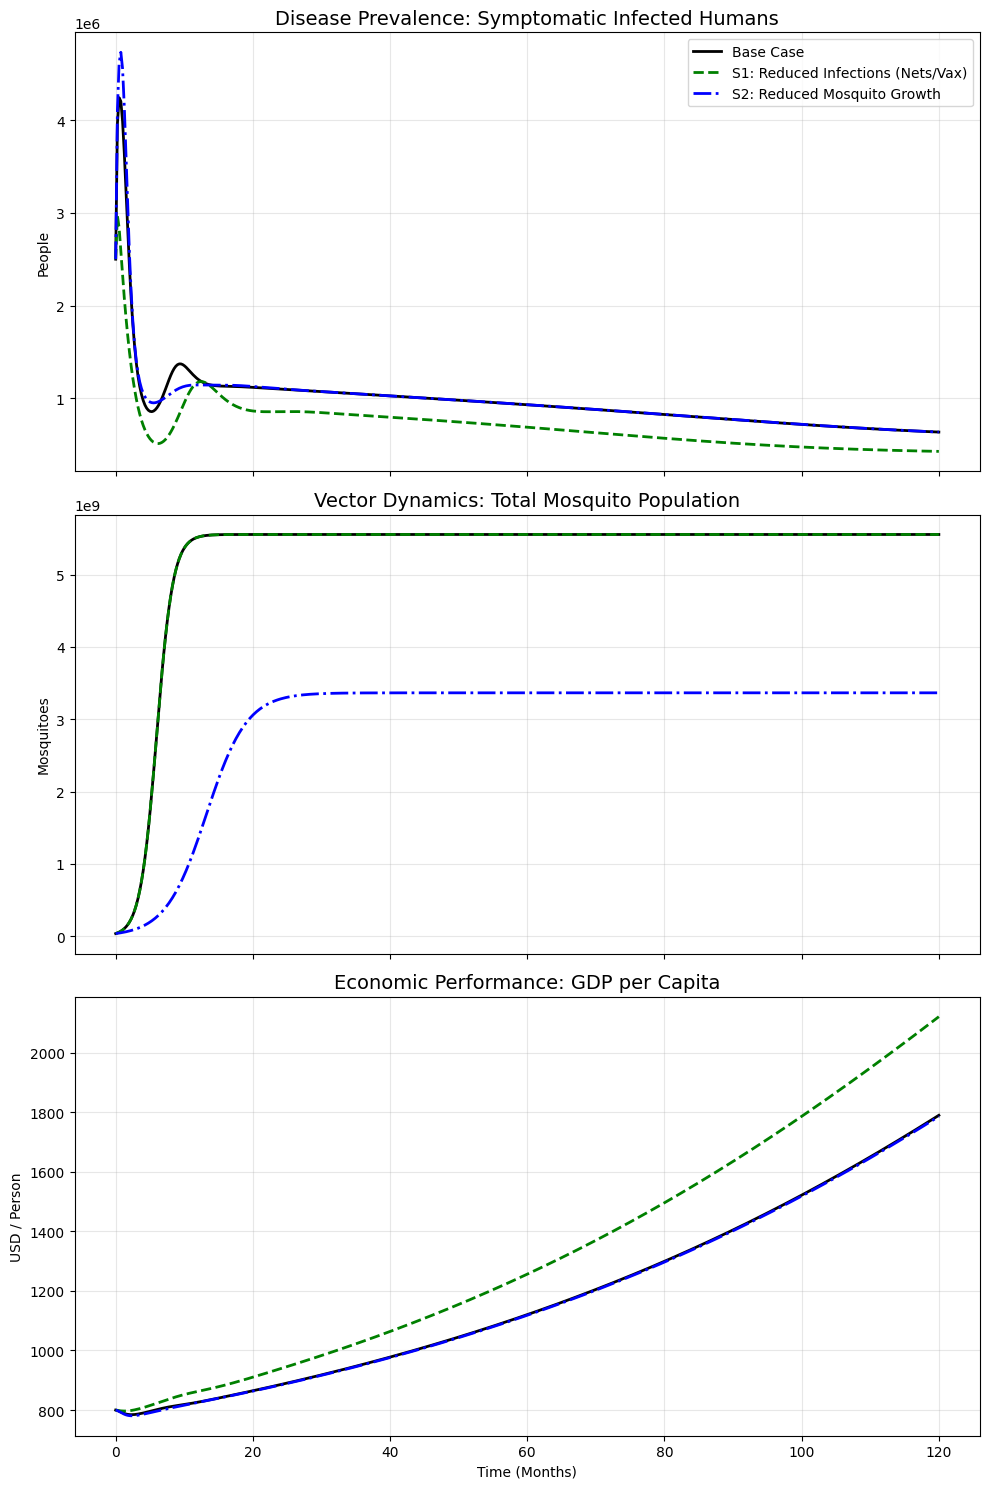

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 1. Model Parameters (Base Case derived from .mdl) ---
params = {
    # Human Population Parameters
    'human_carrying_capacity': 2e7,     #
    'birth_rate_human': 0.005,          #
    'natural_mortality_human': 0.00069, #
    'base_duration_infection': 0.5,     #
    'base_malaria_mortality': 0.05,     #
    'duration_immunity': 6.0,           #

    # Mosquito Parameters
    'mosquito_carrying_capacity': 1e10, #
    'mosquito_repro_rate': 1.5,         #
    'mosquito_life_expectancy': 1.5,    #
    'mosquito_incubation_period': 0.4,  #

    # Transmission & Contact
    'biting_rate': 15.0,                #
    'trans_prob_h_to_m': 0.3,           #
    'trans_prob_m_to_h': 0.3,           #

    # Economic Parameters
    'gdp_max': 4500.0,                  #
    'cost_per_case': 100.0,             #
    'drag_time_constant': 164.0,        #
    'gdp_scale': 1.0                    #
}

# --- 2. The System Dynamics Engine ---
def model(y, t, p):
    """
    State vector y:
    [0] Susceptible Humans (HS)
    [1] Infected Symptomatic Humans (HI)
    [2] Recovered Humans (HR)
    [3] Susceptible Mosquitoes (MS)
    [4] Exposed Mosquitoes (ME)
    [5] Infectious Mosquitoes (MI)
    [6] GDP per Capita (GDP)
    """
    HS, HI, HR, MS, ME, MI, GDP = y

    # Prevent negative populations (numerical stability)
    HS, HI, HR = max(0, HS), max(0, HI), max(0, HR)
    MS, ME, MI = max(0, MS), max(0, ME), max(0, MI)
    GDP = max(0, GDP)

    total_human_pop = HS + HI + HR
    total_mosquito_pop = MS + ME + MI

    # Avoid division by zero
    total_human_safe = max(1.0, total_human_pop)
    total_mosquito_safe = max(1.0, total_mosquito_pop)

    # --- Auxiliary Calculations ---

    # Healthcare Quality
    gdp_ref = GDP / p['gdp_scale']
    # Sigmoid function for healthcare quality based on GDP
    hq_index = 0.05 + 0.75 / (1 + np.exp(-0.00375 * (gdp_ref - 1440)))

    # Infection Rates
    # Human infection rate: how many humans get sick per month
    infection_rate_human = (p['trans_prob_m_to_h'] * p['biting_rate'] * (MI / total_mosquito_safe) * HS)

    # Mosquito infection rate: how many mosquitoes get infected per month
    mosquito_inf_rate = (p['trans_prob_h_to_m'] * p['biting_rate'] * (HI / total_human_safe) * MS)

    # Human Dynamics
    human_births = total_human_pop * p['birth_rate_human'] * (1 - (total_human_pop / p['human_carrying_capacity']))
    recovery_rate = HI * (1 + hq_index) / p['base_duration_infection'] #
    waning_immunity = HR / p['duration_immunity'] #

    malaria_deaths = HI * p['base_malaria_mortality'] * (1 - hq_index) #
    non_malaria_deaths_S = HS * p['natural_mortality_human']
    non_malaria_deaths_I = HI * p['natural_mortality_human']
    non_malaria_deaths_R = HR * p['natural_mortality_human']

    # Mosquito Dynamics
    mosquito_births = total_mosquito_pop * p['mosquito_repro_rate'] * (1 - (total_mosquito_pop / p['mosquito_carrying_capacity']))
    latent_progression = ME / p['mosquito_incubation_period'] #

    mosquito_deaths_S = MS / p['mosquito_life_expectancy']
    mosquito_deaths_E = ME / p['mosquito_life_expectancy']
    mosquito_deaths_I = MI / p['mosquito_life_expectancy']

    # Economic Dynamics
    # Economic Growth
    growth_rate = 0.015 * np.exp(-gdp_ref / 5000)
    economic_growth = GDP * growth_rate

    # Economic Decay/Loss
    econ_loss_malaria = (HI * p['cost_per_case']) / total_human_safe
    non_malaria_loss = (GDP / p['drag_time_constant']) * (GDP / p['gdp_max'])**4
    economic_decay = econ_loss_malaria + non_malaria_loss

    # --- Differential Equations (Flows) ---

    # dHS/dt
    dHS = human_births + waning_immunity - infection_rate_human - non_malaria_deaths_S
    # dHI/dt
    dHI = infection_rate_human - malaria_deaths - recovery_rate - non_malaria_deaths_I
    # dHR/dt
    dHR = recovery_rate - non_malaria_deaths_R - waning_immunity

    # dMS/dt
    dMS = mosquito_births - mosquito_deaths_S - mosquito_inf_rate
    # dME/dt
    dME = mosquito_inf_rate - latent_progression - mosquito_deaths_E
    # dMI/dt
    dMI = latent_progression - mosquito_deaths_I

    # dGDP/dt
    dGDP = economic_growth - economic_decay

    return [dHS, dHI, dHR, dMS, dME, dMI, dGDP]

# --- 3. Simulation Setup ---

# Initial Conditions
# Using exact initial values from the .mdl INTEG definitions
y0 = [
    1.8e7,    # HS: Susceptible Humans
    2.5e6,    # HI: Infected Symptomatic
    0.0,      # HR: Recovered Humans
    3e7,      # MS: Susceptible Mosquitoes
    1e5,      # ME: Exposed Mosquitoes (Initial 100,000)
    8e6,      # MI: Infectious Mosquitoes
    800.0     # GDP per capita
]

# Time vector (Months)
t = np.linspace(0, 120, 120*4) # 10 years (120 months), step 0.25

# --- 4. Run Scenarios ---

# Scenario 0: Base Case
results_base = odeint(model, y0, t, args=(params,))

# Scenario 1: Reduced Human Infections
# Logic: "Strengthens immunity while also reducing effective human-mosquito contact"
# Implementation: Reduce Transmission Probability by 40% (simulating bed nets/vaccine efficacy)
params_s1 = params.copy()
params_s1['trans_prob_m_to_h'] = 0.3 * 0.6  # Reduced from 0.3 to 0.18
params_s1['trans_prob_h_to_m'] = 0.3 * 0.6  # Bed nets work both ways
results_s1 = odeint(model, y0, t, args=(params_s1,))

# Scenario 2: Reduced Mosquito Population Growth
# Logic: "Slows mosquito reproduction ... limits population growth"
# Implementation: Reduce Mosquito Reproduction Rate by 33% (environmental management)
params_s2 = params.copy()
params_s2['mosquito_repro_rate'] = 1.5 * 0.67 # Reduced from 1.5 to ~1.0
results_s2 = odeint(model, y0, t, args=(params_s2,))

# --- 5. Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# Plot 1: Disease Prevalence (Infected Humans)
axes[0].plot(t, results_base[:, 1], 'k-', label='Base Case', linewidth=2)
axes[0].plot(t, results_s1[:, 1], 'g--', label='S1: Reduced Infections (Nets/Vax)', linewidth=2)
axes[0].plot(t, results_s2[:, 1], 'b-.', label='S2: Reduced Mosquito Growth', linewidth=2)
axes[0].set_title('Disease Prevalence: Symptomatic Infected Humans', fontsize=14)
axes[0].set_ylabel('People')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Vector Dynamics (Total Mosquito Population)
total_mosq_base = np.sum(results_base[:, 3:6], axis=1)
total_mosq_s1 = np.sum(results_s1[:, 3:6], axis=1)
total_mosq_s2 = np.sum(results_s2[:, 3:6], axis=1)

axes[1].plot(t, total_mosq_base, 'k-', label='Base Case', linewidth=2)
axes[1].plot(t, total_mosq_s1, 'g--', label='S1: Reduced Infections', linewidth=2)
axes[1].plot(t, total_mosq_s2, 'b-.', label='S2: Reduced Mosquito Growth', linewidth=2)
axes[1].set_title('Vector Dynamics: Total Mosquito Population', fontsize=14)
axes[1].set_ylabel('Mosquitoes')
axes[1].grid(True, alpha=0.3)

# Plot 3: Economic Performance (GDP per Capita)
axes[2].plot(t, results_base[:, 6], 'k-', label='Base Case', linewidth=2)
axes[2].plot(t, results_s1[:, 6], 'g--', label='S1: Reduced Infections', linewidth=2)
axes[2].plot(t, results_s2[:, 6], 'b-.', label='S2: Reduced Mosquito Growth', linewidth=2)
axes[2].set_title('Economic Performance: GDP per Capita', fontsize=14)
axes[2].set_ylabel('USD / Person')
axes[2].set_xlabel('Time (Months)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()